In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    r"E:\Internship\Synent Technology\T-3\netflix_titles.csv"
)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [5]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

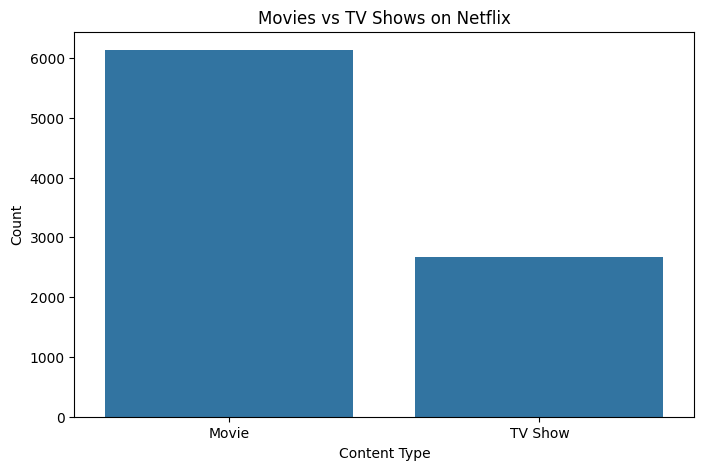

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='type',
    data=df
)

plt.title("Movies vs TV Shows on Netflix")

plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

In [8]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

df['year_added'] = df['date_added'].dt.year

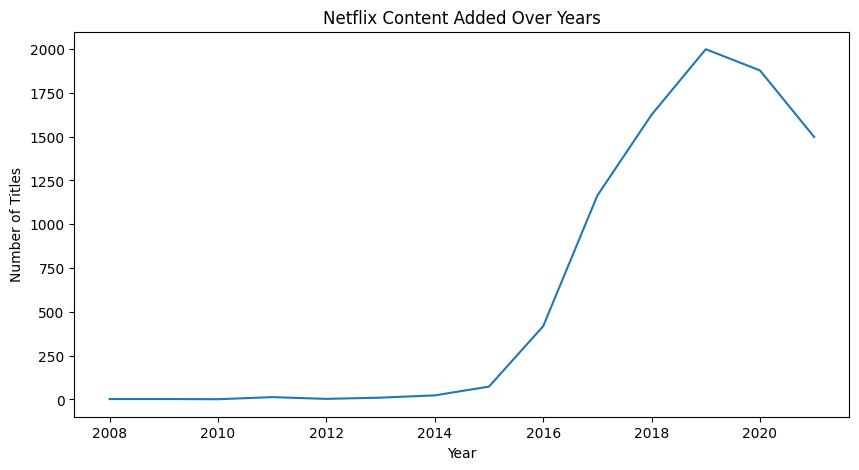

In [9]:
plt.figure(figsize=(10,5))

df['year_added'].value_counts().sort_index().plot()

plt.title("Netflix Content Added Over Years")

plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

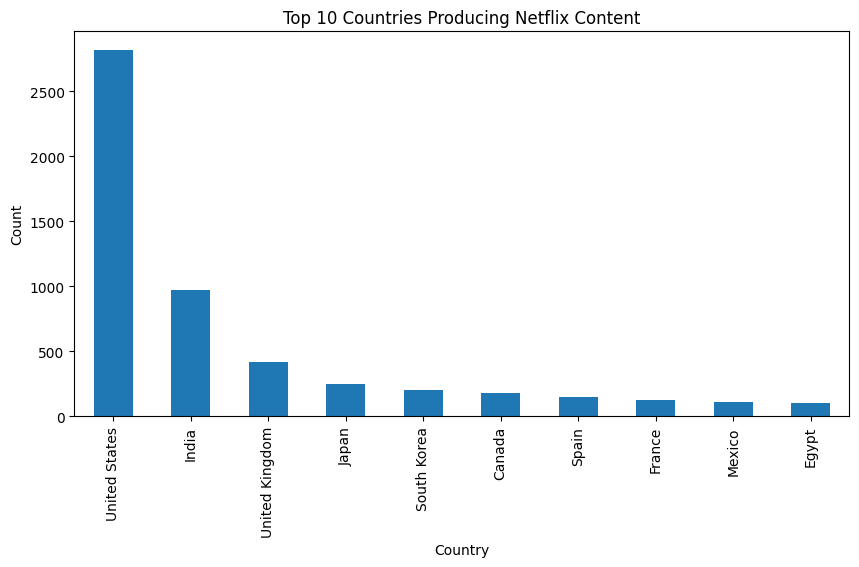

In [10]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries Producing Netflix Content")

plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

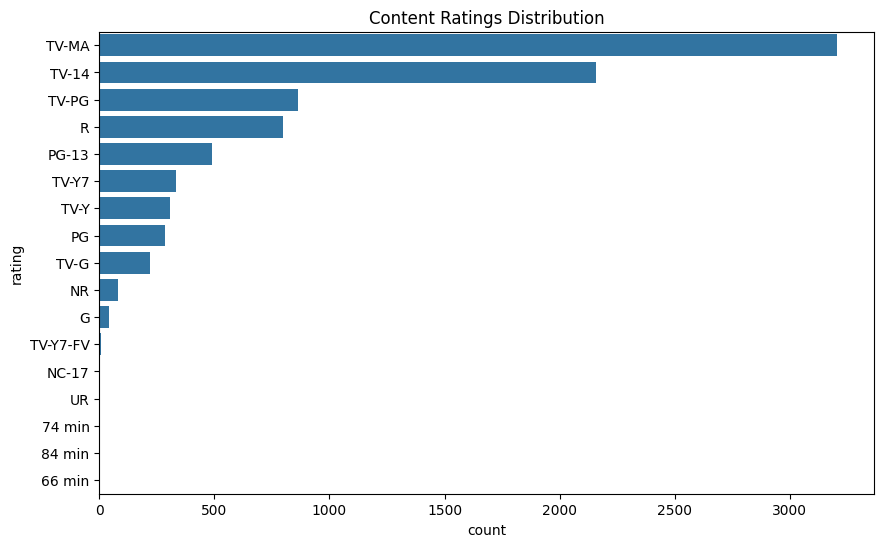

In [11]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Content Ratings Distribution")

plt.show()

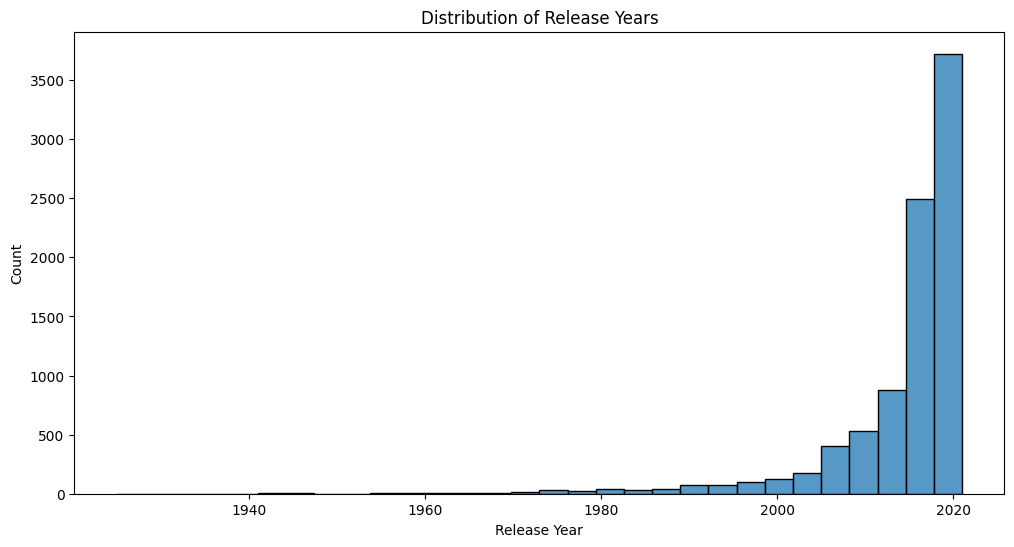

In [12]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['release_year'],
    bins=30
)

plt.title("Distribution of Release Years")

plt.xlabel("Release Year")

plt.show()

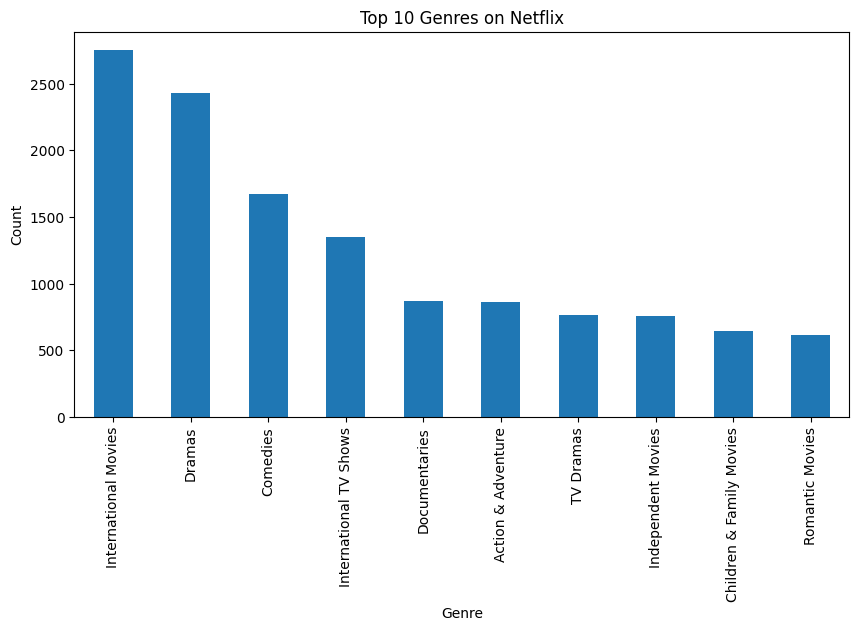

In [13]:
genre_data = df['listed_in'].str.split(', ', expand=True)

all_genres = pd.Series(
    genre_data.values.ravel()
).dropna()

top_genres = all_genres.value_counts().head(10)

plt.figure(figsize=(10,5))

top_genres.plot(kind='bar')

plt.title("Top 10 Genres on Netflix")

plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

In [14]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.corr()

,release_year,year_added
release_year,1.000000,0.110473
year_added,0.110473,1.000000


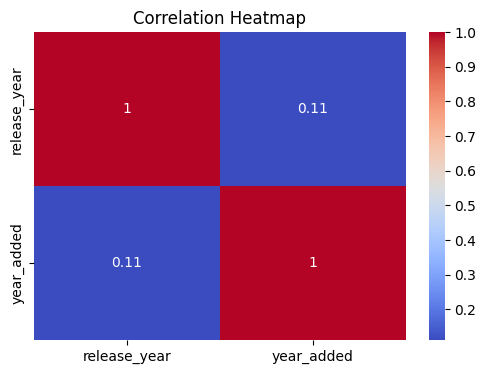

In [15]:
plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [16]:
print("EDA Insights")
print("-"*40)

print("1. Movies are more common than TV Shows.")

print("2. Netflix content increased significantly after 2015.")

print("3. United States contributes the most content.")

print("4. TV-MA is one of the most common ratings.")

print("5. Drama and International Movies are highly represented.")

EDA Insights
----------------------------------------
1. Movies are more common than TV Shows.
2. Netflix content increased significantly after 2015.
3. United States contributes the most content.
4. TV-MA is one of the most common ratings.
5. Drama and International Movies are highly represented.
